Jumlah baris gabungan: 23849

=== Missing Value ===
tanggal     40
kode        37
nama       108
jumlah     107
harga      106
area         0
dtype: int64
Total missing cell: 398

=== Duplikasi ===
Jumlah duplikat: 7502

=== IQR Outlier ===
Q1: 7000.0
Q3: 15000.0
IQR: 8000.0
Lower bound: -5000.0
Upper bound: 27000.0

Jumlah baris setelah cleaning: 14482


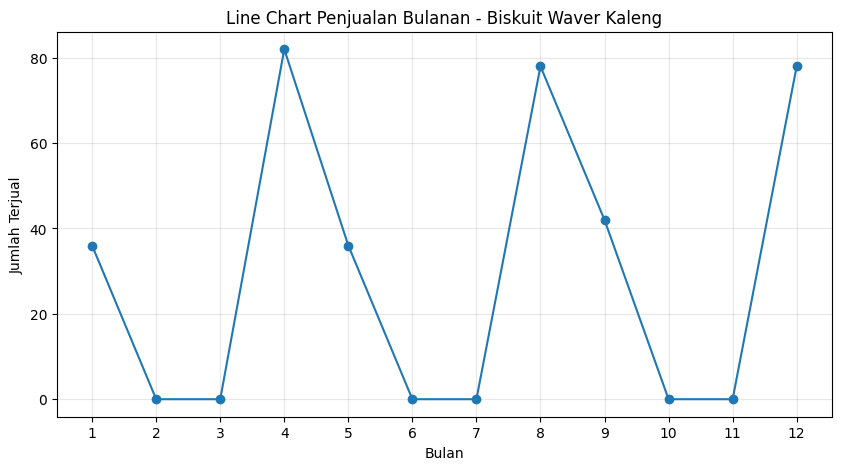

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load data
# =========================
url_yk  = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)

# =========================
# 2. Gabungkan dataset
# =========================
df = pd.concat([df_yk, df_mgl], ignore_index=True)
print("Jumlah baris gabungan:", len(df))

# =========================
# 3. Profiling awal
# =========================
print("\n=== Missing Value ===")
print(df.isna().sum())
print("Total missing cell:", df.isna().sum().sum())

print("\n=== Duplikasi ===")
print("Jumlah duplikat:", df.duplicated().sum())

# =========================
# 4. Cleaning dasar
# =========================
# Ubah tanggal
df['tanggal'] = pd.to_datetime(df['tanggal'], format='%d-%m-%Y', errors='coerce')

# Hapus duplikat
df_clean = df.drop_duplicates().copy()

# Hapus missing value
df_clean = df_clean.dropna(subset=['tanggal', 'kode', 'nama', 'jumlah', 'harga', 'area']).copy()

# =========================
# 5. Removing outlier pada harga (IQR)
# =========================
Q1 = df_clean['harga'].quantile(0.25)
Q3 = df_clean['harga'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n=== IQR Outlier ===")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df_clean = df_clean[(df_clean['harga'] >= lower_bound) & (df_clean['harga'] <= upper_bound)].copy()

print("\nJumlah baris setelah cleaning:", len(df_clean))

# =========================
# 6. Visualisasi line chart per bulan
# =========================
# Ganti nama produk sesuai NIM kamu
produk = "Biskuit Waver Kaleng"

df_produk = df_clean[df_clean['nama'].str.contains(produk, case=False, na=False)].copy()
df_produk['bulan'] = df_produk['tanggal'].dt.month

# total penjualan per bulan (jumlah unit terjual)
monthly = df_produk.groupby('bulan')['jumlah'].sum().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.xticks(range(1, 13))
plt.xlabel("Bulan")
plt.ylabel("Jumlah Terjual")
plt.title(f"Line Chart Penjualan Bulanan - {produk}")
plt.grid(True, alpha=0.3)
plt.show()

Jawaban singkat

Soal A

Dataset digabung menggunakan pd.concat() dan menghasilkan 23.849 baris.
Outlier pada kolom harga dihapus menggunakan metode IQR dengan batas -5.000 sampai 27.000, dan terdeteksi 1.795 baris outlier.
Missing value berjumlah 418 sel, dengan rincian terbesar pada kolom nama, jumlah, dan harga.
Duplikasi dicek dengan duplicated() dan ditemukan 7.502 baris duplikat. Setelah deduplikasi, data menjadi lebih bersih.

Soal B
Untuk produk Biskuit Waver Kaleng, grafik line chart dibuat dengan mengelompokkan data berdasarkan bulan (dt.month) lalu menjumlahkan jumlah per bulan. Hasilnya menunjukkan penjualan aktif pada bulan 1, 4, 5, 8, 9, dan 12.